In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("housing_data.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [3]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [13]:
df.isnull().sum()

,0
FireplaceQu,690
GarageQual,81
SalePrice,0


In [14]:
# null in percentage
df.isnull().mean()*100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


Text(0, 0.5, 'Number of houses')

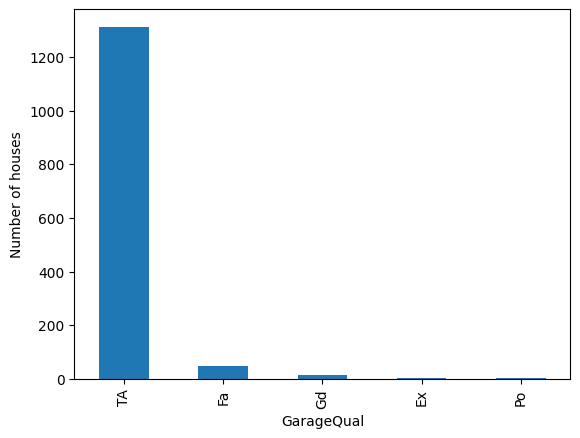

In [7]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [8]:
# so seeing the graph above the most frequent value is TA
# we can also check by
df['GarageQual'].mode()

,GarageQual
0,TA


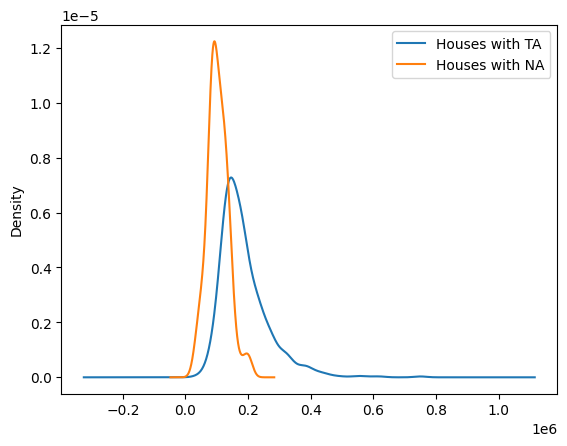

In [15]:
# now lets plot the KDE for this

fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.show()

In [20]:
temp = df[df['GarageQual']=='TA']['SalePrice'] #storing the blue curve

In [21]:
df['GarageQual'].fillna('TA', inplace=True) #imputing the missing values with TA

<Axes: xlabel='GarageQual'>

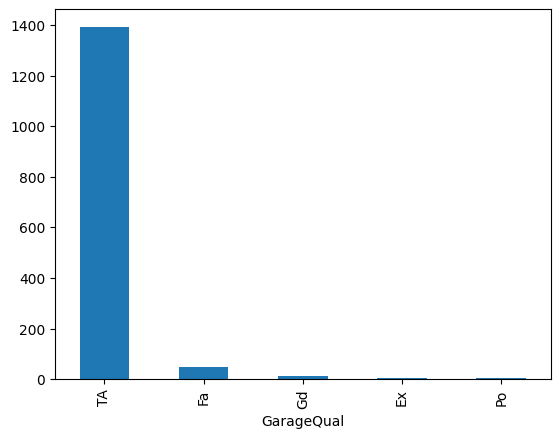

In [19]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

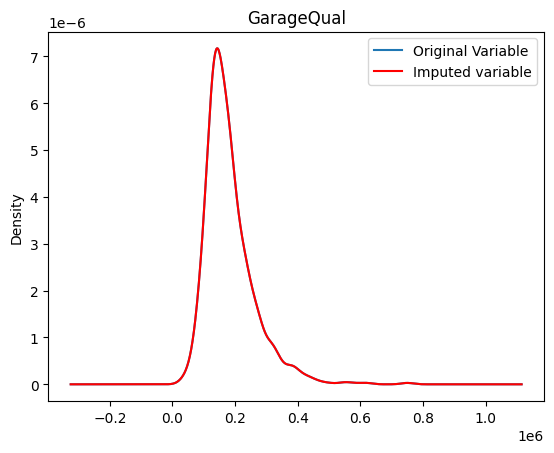

In [23]:
# creating the same graph again
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

#add title
plt.title('GarageQual')


<Axes: xlabel='FireplaceQu'>

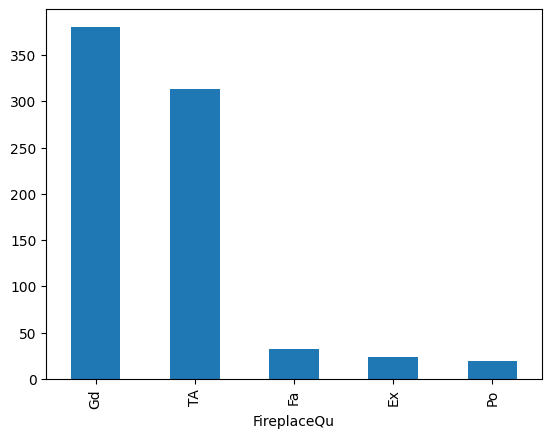

In [24]:
# lets work on that 50 percent data that is fireplacequ
df['FireplaceQu'].value_counts().plot(kind='bar')

In [ ]:
# in the above this should happen since when yu are replacing one category with another then atleast one should dominate all

In [25]:
# lets confirm which one is dominating
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


Text(0.5, 1.0, 'FireplaceQu')

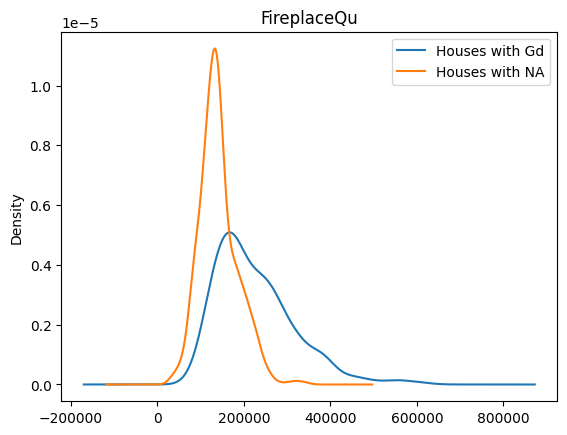

In [26]:
#again creating the same graph we ahve
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax)

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [28]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [29]:
df['FireplaceQu'].fillna('Gd', inplace=True)

/tmp/ipykernel_2036/3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

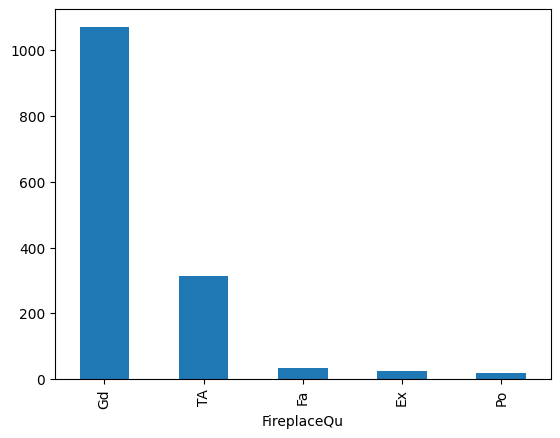

In [30]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [ ]:
# now we can see that its more and enough after imputing with gd

Text(0.5, 1.0, 'FireplaceQu')

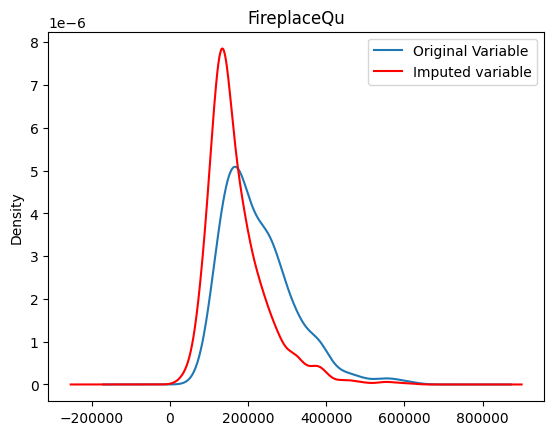

In [31]:
# creating the same graph again
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original Variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

#add title
plt.title('FireplaceQu')

In [ ]:
# now using sklearn these things becomes very easy

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'], test_size=0.2)

In [33]:
from sklearn.impute import SimpleImputer

In [34]:
imputer = SimpleImputer(strategy='most_frequent')

In [35]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [36]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)